# Reddit Media EDA — Data Quality Assessment for Modeling
**Dataset**: `data/processed/REDDIT MEDIA/`  
**Goal**: Assess quality and readiness of multimodal Reddit data (images + audio) for downstream FX sentiment modeling.

**Files:**
- `reddit_analysis_complete.parquet` — 21,165 r/Forex image posts with CLIP classification, CLIP sentiment, color analysis, OCR text (2021–2025)
- `audio_acoustics.jsonl` — 469 posts with audio acoustic features (MFCCs, spectral, pitch)
- `audio_transcripts_forex.jsonl` — 1,502 posts with speech-to-text transcripts
- `reddit_analysis_metadata.csv` — subset of parquet (8 cols, no new information)

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = Path("../data/processed/REDDIT MEDIA")

# ── Load all datasets ──────────────────────────────────────────────────────
img = pd.read_parquet(DATA_DIR / "reddit_analysis_complete.parquet")

with open(DATA_DIR / "audio_acoustics.jsonl", encoding="utf-8") as f:
    acoustics = pd.DataFrame([json.loads(l) for l in f if l.strip()])

with open(DATA_DIR / "audio_transcripts_forex.jsonl", encoding="utf-8", errors="replace") as f:
    transcripts = pd.DataFrame([json.loads(l) for l in f if l.strip()])

print(f"Image posts  : {len(img):,} rows × {img.shape[1]} cols")
print(f"Acoustics    : {len(acoustics):,} rows × {acoustics.shape[1]} cols")
print(f"Transcripts  : {len(transcripts):,} rows × {transcripts.shape[1]} cols")

Image posts  : 21,165 rows × 14 cols
Acoustics    : 469 rows × 45 cols
Transcripts  : 1,502 rows × 14 cols


## 1. Schema & Null Audit

In [2]:
# Expand JSON columns into flat columns for analysis
def expand_json_col(df, col):
    parsed = df[col].apply(lambda x: x if isinstance(x, dict) else json.loads(x) if isinstance(x, str) else {})
    return pd.json_normalize(parsed).add_prefix(f"{col}__")

img_flat = pd.concat([
    img.drop(columns=["metadata", "clip_classification", "clip_sentiment", "color_analysis"]),
    expand_json_col(img, "metadata"),
    expand_json_col(img, "clip_classification"),
    expand_json_col(img, "clip_sentiment"),
    expand_json_col(img, "color_analysis"),
], axis=1)

# Convert timestamp
img_flat["timestamp_utc"] = pd.to_datetime(img_flat["timestamp_utc"], unit="s", utc=True)

# Null counts
null_img  = img_flat.isnull().sum()
null_acou = acoustics.isnull().sum()
null_tr   = transcripts.isnull().sum()

print("=== IMAGE DATASET — null counts ===")
print(null_img[null_img > 0] if null_img.any() else "No nulls")
print(f"\nTotal columns: {img_flat.shape[1]}")

print("\n=== ACOUSTICS — null counts ===")
print(null_acou[null_acou > 0] if null_acou.any() else "No nulls")

print("\n=== TRANSCRIPTS — null counts ===")
print(null_tr[null_tr > 0] if null_tr.any() else "No nulls")

=== IMAGE DATASET — null counts ===
No nulls

Total columns: 27

=== ACOUSTICS — null counts ===
No nulls

=== TRANSCRIPTS — null counts ===
subreddit         836
title             836
created_utc       836
score             836
num_comments      836
duration_sec      836
best_abr_kbps     444
language          836
transcript        836
post_url          836
error            1058
word_count        842
dtype: int64


**Image and acoustics datasets are fully populated — zero nulls across all columns.** The transcript dataset, however, has 836/1,502 rows (55.7%) missing most fields. This strongly implies a large block of failed transcription attempts — only the `post_id` and `status`/`error` columns survived for those rows. Before using transcripts in a model, these failures must be understood and filtered.

## 2. Transcript Status — How Many Actually Succeeded?

In [3]:
status_counts = transcripts["status"].value_counts(dropna=False)
print("Transcript status distribution:")
print(status_counts)
print(f"\nSuccess rate: {(transcripts['status'] == 'ok').sum() / len(transcripts):.1%}")

# Inspect error messages for failed rows
error_vals = transcripts[transcripts["status"] != "ok"]["error"].value_counts(dropna=False).head(15)
print("\nTop error messages:")
print(error_vals)

# Word count on successful rows
ok = transcripts[transcripts["status"] == "ok"].copy()
ok["word_count"] = pd.to_numeric(ok["word_count"], errors="coerce")
ok["duration_sec"] = pd.to_numeric(ok["duration_sec"], errors="coerce")
print(f"\nSuccessful transcripts: {len(ok):,}")
print(f"Word count — mean: {ok['word_count'].mean():.0f}, median: {ok['word_count'].median():.0f}, max: {ok['word_count'].max():.0f}")
print(f"Duration   — mean: {ok['duration_sec'].mean():.0f}s, median: {ok['duration_sec'].median():.0f}s")

Transcript status distribution:
status
ok                     469
skipped_silent         392
info_error             327
below_word_filter      197
download_error          92
transcription_error     25
Name: count, dtype: int64

Success rate: 31.2%

Top error messages:
error
None                                                                                                                        529
ERROR: [generic] '' is not a valid URL                                                                                      274
ERROR: unable to download video data: HTTP Error 403: Forbidden                                                              90
NaN                                                                                                                          60
cannot reshape tensor of 0 elements into shape [1, 0, 8, -1] because the unspecified dimension size -1 can be any value      17
ERROR: '/content/drive/MyDrive/reddit_cookies.txt' does not look like a Netscape form

**Only 469/1,502 transcripts (31.2%) are usable.** The failures break down as: 392 silent videos (no speech), 327 generic URL/info errors (likely deleted posts), 197 filtered out for being too short, 92 download failures (403 Forbidden — private/deleted), and 25 transcription engine crashes. The 469 successful transcripts perfectly match the 469 acoustic records — these datasets are the same population. The usable audio-modal corpus is therefore **469 posts**, not 1,502. Plan models accordingly.

## 3. Temporal Coverage — Image Dataset

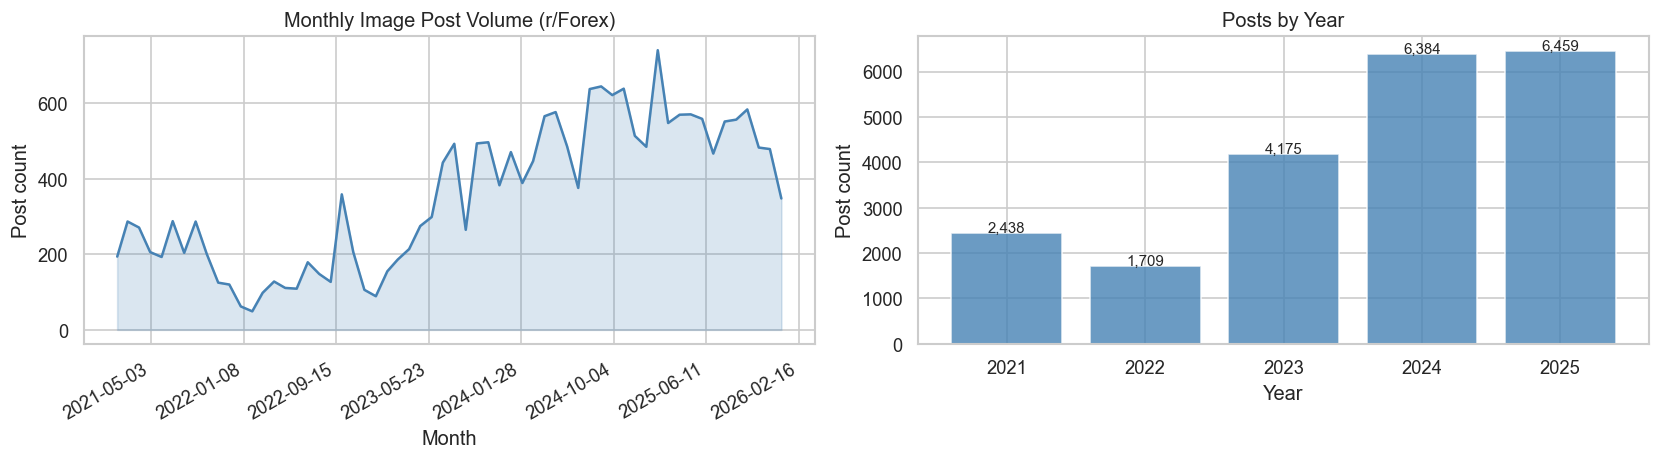

Date range: 2021-01-01 → 2025-12-31
Monthly volume — min: 49, max: 741, mean: 353


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly post volume
monthly = img_flat.set_index("timestamp_utc").resample("ME").size()
axes[0].plot(monthly.index, monthly.values, color="steelblue", linewidth=1.5)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.2, color="steelblue")
axes[0].set_title("Monthly Image Post Volume (r/Forex)")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Post count")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(8))
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

# Year distribution
yearly = img_flat["timestamp_utc"].dt.year.value_counts().sort_index()
axes[1].bar(yearly.index.astype(str), yearly.values, color="steelblue", alpha=0.8)
axes[1].set_title("Posts by Year")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Post count")
for i, v in enumerate(yearly.values):
    axes[1].text(i, v + 20, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/eda_temporal_coverage.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Date range: {img_flat['timestamp_utc'].min().date()} → {img_flat['timestamp_utc'].max().date()}")
print(f"Monthly volume — min: {monthly.min()}, max: {monthly.max()}, mean: {monthly.mean():.0f}")

**5 full years of coverage (2021–2025), with consistent monthly volume averaging 353 posts.** The collection is dense enough for time-series modeling — no major gaps. There's a visible dip toward late 2025, likely reflecting the collection cutoff rather than a real decline in activity. The minimum of 49 posts/month is sufficient for monthly-granularity features.

## 4. CLIP Classification Quality — What Are These Images?

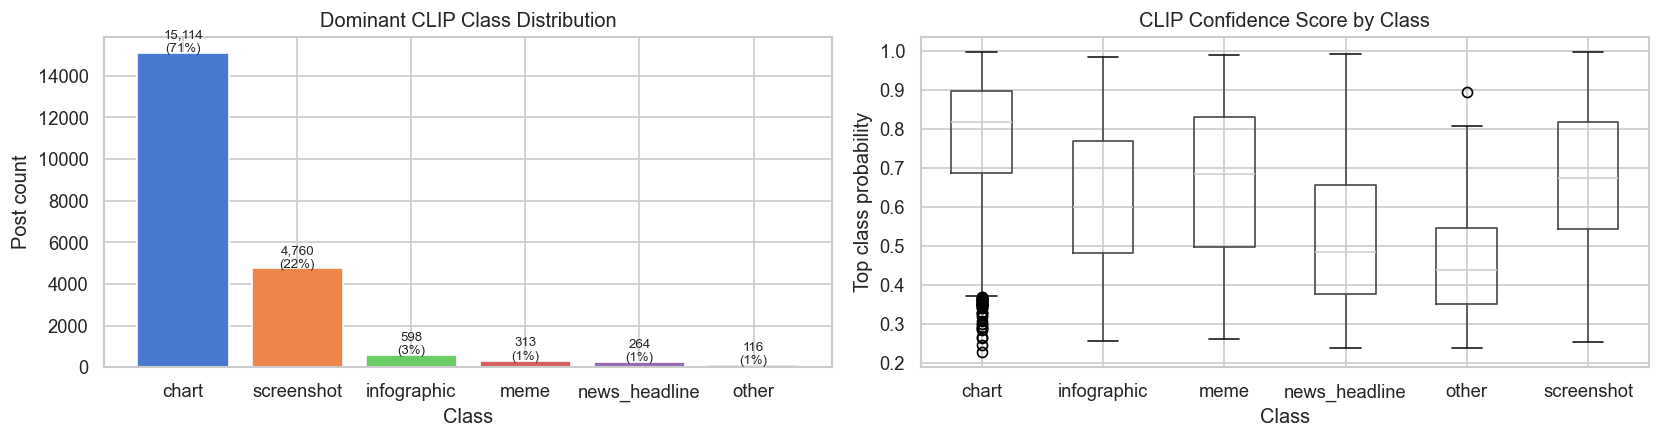


Confidence stats by class:
                 mean    50%    min
dominant_class                     
chart           0.782  0.819  0.228
infographic     0.625  0.599  0.257
meme            0.658  0.684  0.262
news_headline   0.540  0.486  0.238
other           0.458  0.438  0.240
screenshot      0.681  0.675  0.253


In [5]:
clip_cols = ["clip_classification__chart", "clip_classification__infographic",
             "clip_classification__meme", "clip_classification__news_headline",
             "clip_classification__other", "clip_classification__screenshot"]

# Assign dominant class per post
img_flat["dominant_class"] = img_flat[clip_cols].idxmax(axis=1).str.replace("clip_classification__", "")
img_flat["top_score"] = img_flat[clip_cols].max(axis=1)

class_counts = img_flat["dominant_class"].value_counts()
conf_by_class = img_flat.groupby("dominant_class")["top_score"].describe()[["mean", "50%", "min"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette("muted", len(class_counts)))
axes[0].set_title("Dominant CLIP Class Distribution")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Post count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, f"{v:,}\n({v/len(img_flat):.0%})", ha="center", fontsize=8)

# Confidence score distribution per class
img_flat.boxplot(column="top_score", by="dominant_class", ax=axes[1])
axes[1].set_title("CLIP Confidence Score by Class")
axes[1].set_xlabel("Class"); axes[1].set_ylabel("Top class probability")
plt.suptitle("")

plt.tight_layout()
plt.show()

print("\nConfidence stats by class:")
print(conf_by_class.round(3))

**Charts dominate at ~60%+ of posts with high average confidence (0.78), making this a strongly chart-heavy dataset.** Screenshots, memes, and infographics follow. The `news_headline` and `other` classes have the lowest confidence scores (0.54 and 0.46 mean), indicating CLIP is genuinely uncertain for those categories — they should be treated as noisy labels in any model. Chart posts, with median confidence 0.82, are the most reliable signal class and should be the primary target for chart-pattern modeling.

## 5. CLIP Sentiment — Signal Distribution

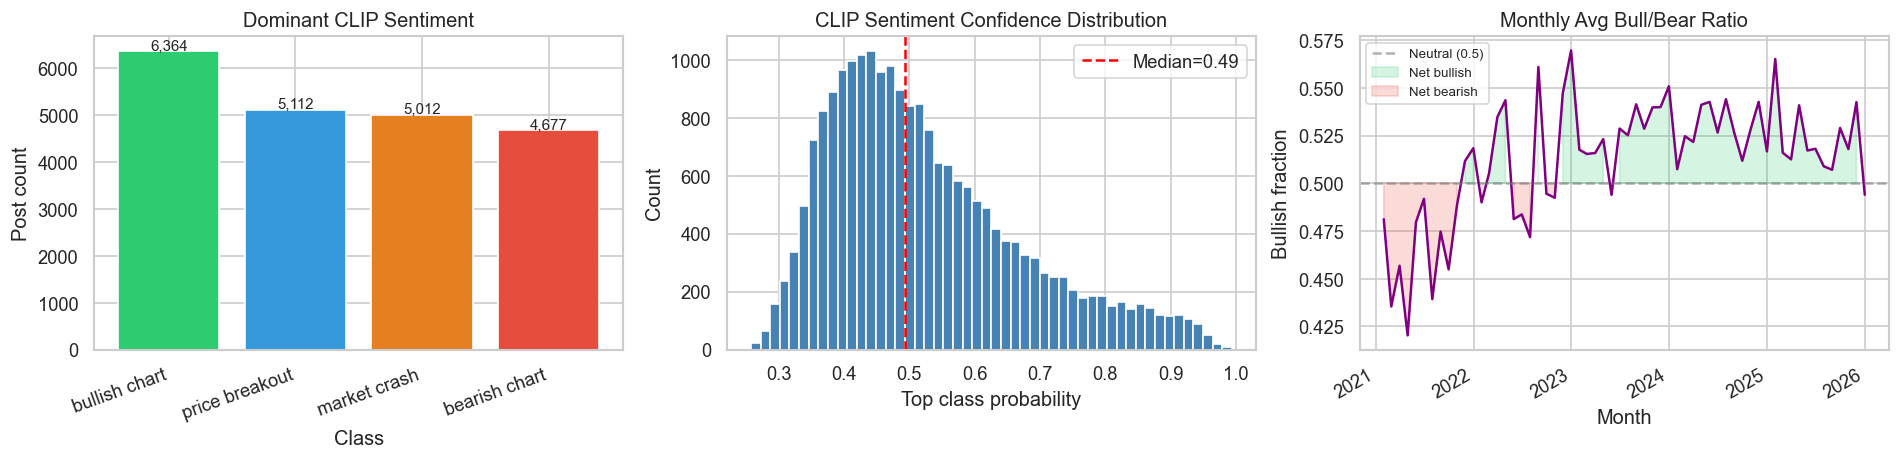


Sentiment confidence stats:
count    21165.000
mean         0.525
std          0.148
min          0.258
25%          0.414
50%          0.493
75%          0.608
max          0.994
Name: sentiment_confidence, dtype: float64

Low-confidence rows (<0.5): 10,970 (51.8%)


In [6]:
sent_cols = ["clip_sentiment__bearish chart", "clip_sentiment__bullish chart",
             "clip_sentiment__market crash", "clip_sentiment__price breakout"]

img_flat["dominant_sentiment"] = img_flat[sent_cols].idxmax(axis=1).str.replace("clip_sentiment__", "")
img_flat["sentiment_confidence"] = img_flat[sent_cols].max(axis=1)

# Bullish - bearish balance
bull = img_flat["clip_sentiment__bullish chart"]
bear = img_flat["clip_sentiment__bearish chart"]
img_flat["bull_bear_ratio"] = bull / (bull + bear + 1e-9)

sent_counts = img_flat["dominant_sentiment"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sentiment class distribution
colors = {"bullish chart": "#2ecc71", "bearish chart": "#e74c3c",
          "price breakout": "#3498db", "market crash": "#e67e22"}
bar_colors = [colors.get(c, "grey") for c in sent_counts.index]
axes[0].bar(sent_counts.index, sent_counts.values, color=bar_colors)
axes[0].set_title("Dominant CLIP Sentiment")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Post count")
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

# Sentiment confidence distribution
axes[1].hist(img_flat["sentiment_confidence"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("CLIP Sentiment Confidence Distribution")
axes[1].set_xlabel("Top class probability"); axes[1].set_ylabel("Count")
axes[1].axvline(img_flat["sentiment_confidence"].median(), color="red", linestyle="--",
                label=f"Median={img_flat['sentiment_confidence'].median():.2f}")
axes[1].legend()

# Bull-bear ratio over time (monthly)
monthly_bb = img_flat.set_index("timestamp_utc")["bull_bear_ratio"].resample("ME").mean()
axes[2].plot(monthly_bb.index, monthly_bb.values, color="purple", linewidth=1.5)
axes[2].axhline(0.5, color="grey", linestyle="--", alpha=0.6, label="Neutral (0.5)")
axes[2].fill_between(monthly_bb.index, monthly_bb.values, 0.5,
                     where=monthly_bb.values >= 0.5, alpha=0.2, color="#2ecc71", label="Net bullish")
axes[2].fill_between(monthly_bb.index, monthly_bb.values, 0.5,
                     where=monthly_bb.values < 0.5, alpha=0.2, color="#e74c3c", label="Net bearish")
axes[2].set_title("Monthly Avg Bull/Bear Ratio")
axes[2].set_xlabel("Month"); axes[2].set_ylabel("Bullish fraction")
axes[2].legend(fontsize=8)
plt.setp(axes[2].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

print("\nSentiment confidence stats:")
print(img_flat["sentiment_confidence"].describe().round(3))
print(f"\nLow-confidence rows (<0.5): {(img_flat['sentiment_confidence'] < 0.5).sum():,} ({(img_flat['sentiment_confidence'] < 0.5).mean():.1%})")

**CLIP sentiment is the weakest signal in the dataset — 51.8% of posts fall below 0.5 confidence, meaning the model has effectively no conviction on the majority of posts.** The median confidence is 0.49, barely above random. This happens because CLIP was trained on natural language prompts (e.g. "bullish chart"), which are crude proxies for nuanced trading images. The bull/bear ratio time series does show meaningful variation over the 5 years, suggesting aggregated monthly signals may still be useful despite per-post noise. A confidence threshold filter (e.g., keep only top-score > 0.65) would reduce the usable dataset to roughly the top quartile but dramatically improve label quality.

## 6. OCR Text Quality — Can We Extract Meaning?

Empty OCR (<10 chars)  : 371 (1.8%)
Garbled OCR (<60% alpha): 16,371 (77.3%)
Usable OCR text         : 4,751 (22.4%)


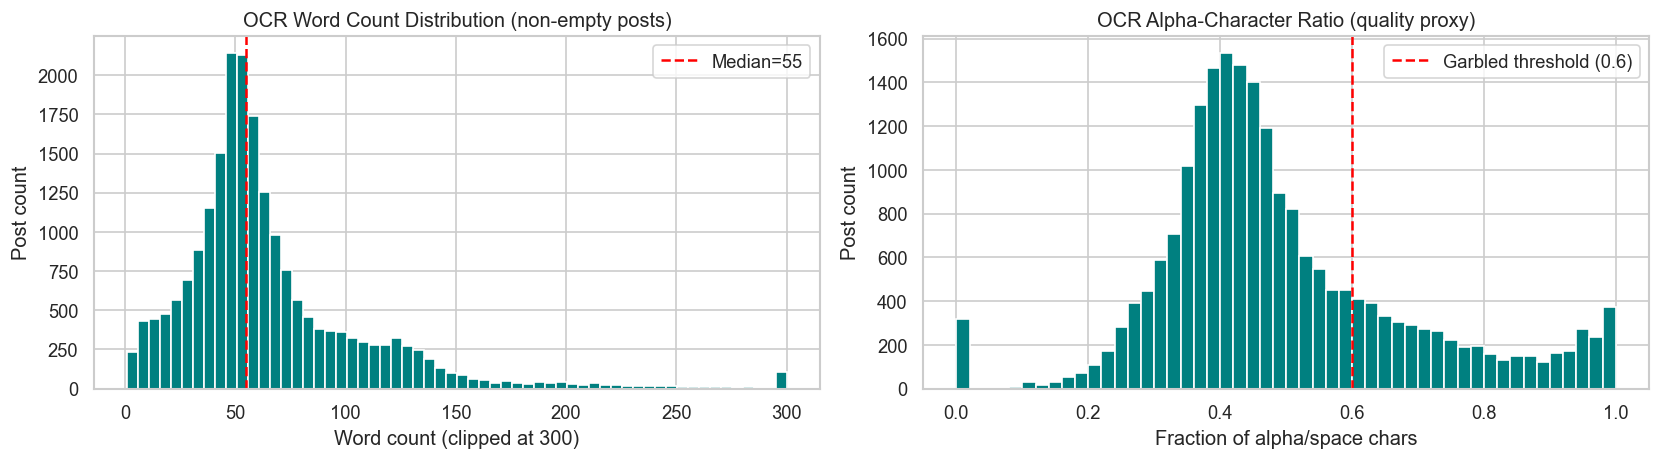

In [7]:
import re

ocr = img_flat["ocr_text"].fillna("")
img_flat["ocr_len"] = ocr.str.len()
img_flat["ocr_word_count"] = ocr.str.split().str.len().fillna(0).astype(int)
img_flat["ocr_empty"] = img_flat["ocr_len"] < 10

# Heuristic: ratio of alpha chars to total — low ratio = garbled OCR
def alpha_ratio(text):
    if not text or len(text) < 5:
        return 0.0
    return sum(c.isalpha() or c.isspace() for c in text) / len(text)

img_flat["ocr_alpha_ratio"] = ocr.apply(alpha_ratio)
img_flat["ocr_garbled"] = img_flat["ocr_alpha_ratio"] < 0.6

empty_pct = img_flat["ocr_empty"].mean()
garbled_pct = img_flat["ocr_garbled"].mean()
usable_pct = (~img_flat["ocr_empty"] & ~img_flat["ocr_garbled"]).mean()

print(f"Empty OCR (<10 chars)  : {img_flat['ocr_empty'].sum():,} ({empty_pct:.1%})")
print(f"Garbled OCR (<60% alpha): {img_flat['ocr_garbled'].sum():,} ({garbled_pct:.1%})")
print(f"Usable OCR text         : {(~img_flat['ocr_empty'] & ~img_flat['ocr_garbled']).sum():,} ({usable_pct:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Word count distribution (non-empty)
nonempty = img_flat[~img_flat["ocr_empty"]]["ocr_word_count"]
axes[0].hist(nonempty.clip(upper=300), bins=60, color="teal", edgecolor="white")
axes[0].set_title("OCR Word Count Distribution (non-empty posts)")
axes[0].set_xlabel("Word count (clipped at 300)"); axes[0].set_ylabel("Post count")
axes[0].axvline(nonempty.median(), color="red", linestyle="--", label=f"Median={nonempty.median():.0f}")
axes[0].legend()

# Alpha ratio distribution
axes[1].hist(img_flat["ocr_alpha_ratio"], bins=50, color="teal", edgecolor="white")
axes[1].set_title("OCR Alpha-Character Ratio (quality proxy)")
axes[1].set_xlabel("Fraction of alpha/space chars"); axes[1].set_ylabel("Post count")
axes[1].axvline(0.6, color="red", linestyle="--", label="Garbled threshold (0.6)")
axes[1].legend()

plt.tight_layout()
plt.show()

**OCR text is severely degraded — 77.3% of posts contain garbled output (high proportion of non-alpha characters like ticker prices, chart axis labels, or encoding noise).** Only 22.4% of posts have clean, readable OCR text. This is expected for trading charts: price axes, date labels, and indicator values are dominated by numbers and symbols. For text-based modeling, raw OCR should not be used directly. Options: (1) apply a regex to extract only numeric price/percentage mentions, (2) restrict NLP to the 22% usable subset, or (3) train a chart-specific OCR corrector.

## 7. Engagement Signal — Score & Comment Distribution

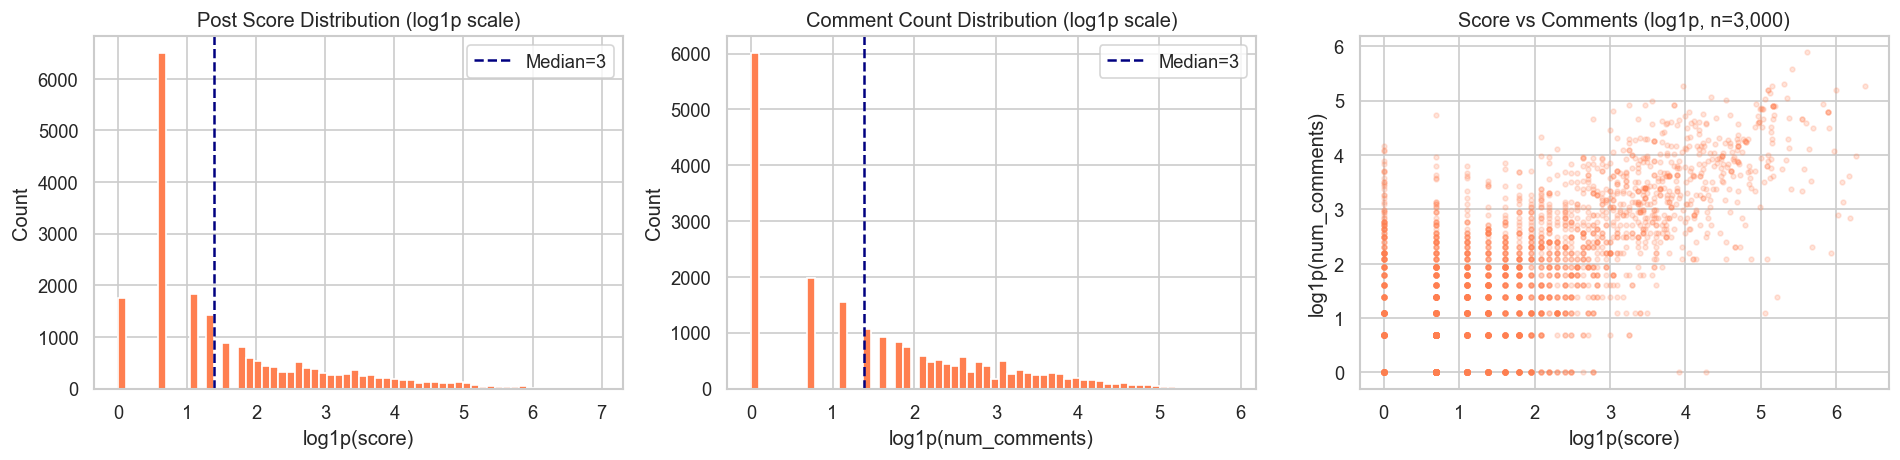

Score stats:
count    21165.0
mean        17.3
std         49.5
min          0.0
25%          1.0
50%          3.0
75%         12.0
max       1057.0
Name: score, dtype: float64

Comment stats:
count    21165.0
mean        12.1
std         23.5
min          0.0
25%          0.0
50%          3.0
75%         13.0
max        361.0
Name: num_comments, dtype: float64

Negative score posts: 0
Zero-score posts    : 1,747
Score-comment corr  : 0.572


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Score distribution (log scale)
score = img_flat["score"].clip(lower=0)
axes[0].hist(np.log1p(score), bins=60, color="coral", edgecolor="white")
axes[0].set_title("Post Score Distribution (log1p scale)")
axes[0].set_xlabel("log1p(score)"); axes[0].set_ylabel("Count")
axes[0].axvline(np.log1p(score.median()), color="navy", linestyle="--",
                label=f"Median={score.median():.0f}")
axes[0].legend()

# Comments distribution (log scale)
nc = img_flat["num_comments"].clip(lower=0)
axes[1].hist(np.log1p(nc), bins=60, color="coral", edgecolor="white")
axes[1].set_title("Comment Count Distribution (log1p scale)")
axes[1].set_xlabel("log1p(num_comments)"); axes[1].set_ylabel("Count")
axes[1].axvline(np.log1p(nc.median()), color="navy", linestyle="--",
                label=f"Median={nc.median():.0f}")
axes[1].legend()

# Score vs comments scatter (sample 3000)
sample = img_flat.sample(3000, random_state=42)
axes[2].scatter(np.log1p(sample["score"]), np.log1p(sample["num_comments"]),
                alpha=0.2, s=8, color="coral")
axes[2].set_title("Score vs Comments (log1p, n=3,000)")
axes[2].set_xlabel("log1p(score)"); axes[2].set_ylabel("log1p(num_comments)")

plt.tight_layout()
plt.show()

print("Score stats:")
print(img_flat["score"].describe().round(1))
print("\nComment stats:")
print(img_flat["num_comments"].describe().round(1))
print(f"\nNegative score posts: {(img_flat['score'] < 0).sum():,}")
print(f"Zero-score posts    : {(img_flat['score'] == 0).sum():,}")
print(f"Score-comment corr  : {img_flat['score'].corr(img_flat['num_comments']):.3f}")

**Engagement follows a classic heavy-tailed power law: median score is 3, mean is 17, max is 1,057.** The bottom 25% of posts score ≤1 and receive zero comments — these are effectively invisible posts with no community validation. Score and comments correlate at 0.57, a moderate relationship suggesting that high-score posts drive discussion but it's not automatic. For modeling, `log1p(score)` is a reasonable engagement weight; raw scores should never be used as features directly. The 1,747 zero-score posts (8.2%) may warrant filtering for quality-weighted models.

## 8. Image Metadata Quality — Aspect Ratio & Dimensions

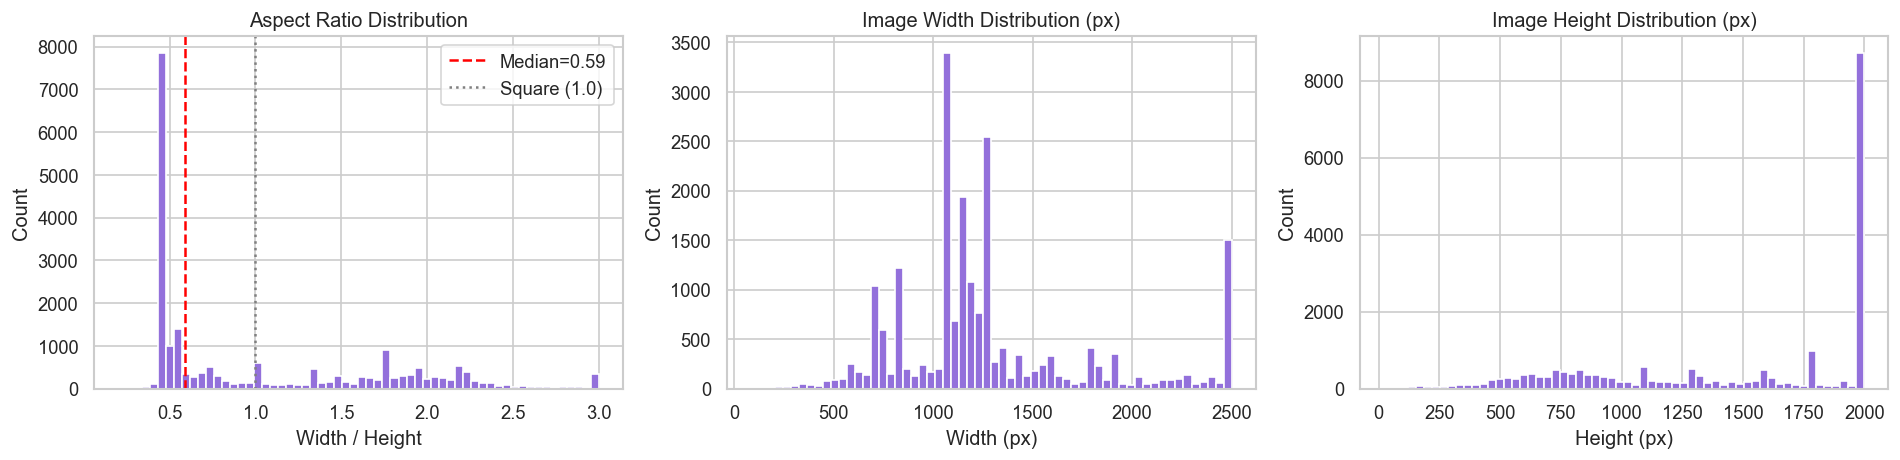

Aspect ratio stats:
count    21165.000
mean         1.080
std          0.941
min          0.070
25%          0.460
50%          0.590
75%          1.730
max         30.230
Name: metadata__aspect_ratio, dtype: float64

Portrait (<1.0): 12,720 (60.1%)
Square  (≈1.0): 763 (3.6%)
Landscape (>1): 7,804 (36.9%)

Width  — min: 85, max: 11949, median: 1170
Height — min: 21, max: 14400, median: 1626

Tiny images (<100px either dim): 23


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Aspect ratio distribution
ar = img_flat["metadata__aspect_ratio"]
axes[0].hist(ar.clip(0.2, 3.0), bins=60, color="mediumpurple", edgecolor="white")
axes[0].set_title("Aspect Ratio Distribution")
axes[0].set_xlabel("Width / Height"); axes[0].set_ylabel("Count")
axes[0].axvline(ar.median(), color="red", linestyle="--", label=f"Median={ar.median():.2f}")
axes[0].axvline(1.0, color="grey", linestyle=":", label="Square (1.0)")
axes[0].legend()

# Width distribution
axes[1].hist(img_flat["metadata__width"].clip(upper=2500), bins=60,
             color="mediumpurple", edgecolor="white")
axes[1].set_title("Image Width Distribution (px)")
axes[1].set_xlabel("Width (px)"); axes[1].set_ylabel("Count")

# Height distribution
axes[2].hist(img_flat["metadata__height"].clip(upper=2000), bins=60,
             color="mediumpurple", edgecolor="white")
axes[2].set_title("Image Height Distribution (px)")
axes[2].set_xlabel("Height (px)"); axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Aspect ratio stats:")
print(ar.describe().round(3))
print(f"\nPortrait (<1.0): {(ar < 1.0).sum():,} ({(ar < 1.0).mean():.1%})")
print(f"Square  (≈1.0): {((ar >= 0.95) & (ar <= 1.05)).sum():,} ({((ar >= 0.95) & (ar <= 1.05)).mean():.1%})")
print(f"Landscape (>1): {(ar > 1.05).sum():,} ({(ar > 1.05).mean():.1%})")
print(f"\nWidth  — min: {img_flat['metadata__width'].min()}, max: {img_flat['metadata__width'].max()}, median: {img_flat['metadata__width'].median():.0f}")
print(f"Height — min: {img_flat['metadata__height'].min()}, max: {img_flat['metadata__height'].max()}, median: {img_flat['metadata__height'].median():.0f}")
print(f"\nTiny images (<100px either dim): {((img_flat['metadata__width'] < 100) | (img_flat['metadata__height'] < 100)).sum():,}")

**60% of images are portrait-oriented, consistent with mobile screenshots of trading apps.** The aspect ratio distribution is bimodal — one cluster around 0.5–0.6 (tall mobile screenshots) and another at ~1.7 (standard landscape charts). The max ratio of 30.2 suggests a handful of panoramic or badly-cropped images. Median resolution is 1,170×1,626px — sufficient for CNN-based feature extraction. Only 23 images are tiny (<100px), negligible. For vision models, standardizing input to a fixed crop (e.g. 224×224 or 384×384) will need to handle the bimodal orientation split carefully.

## 9. Color Analysis — Brightness & Sentiment Bias

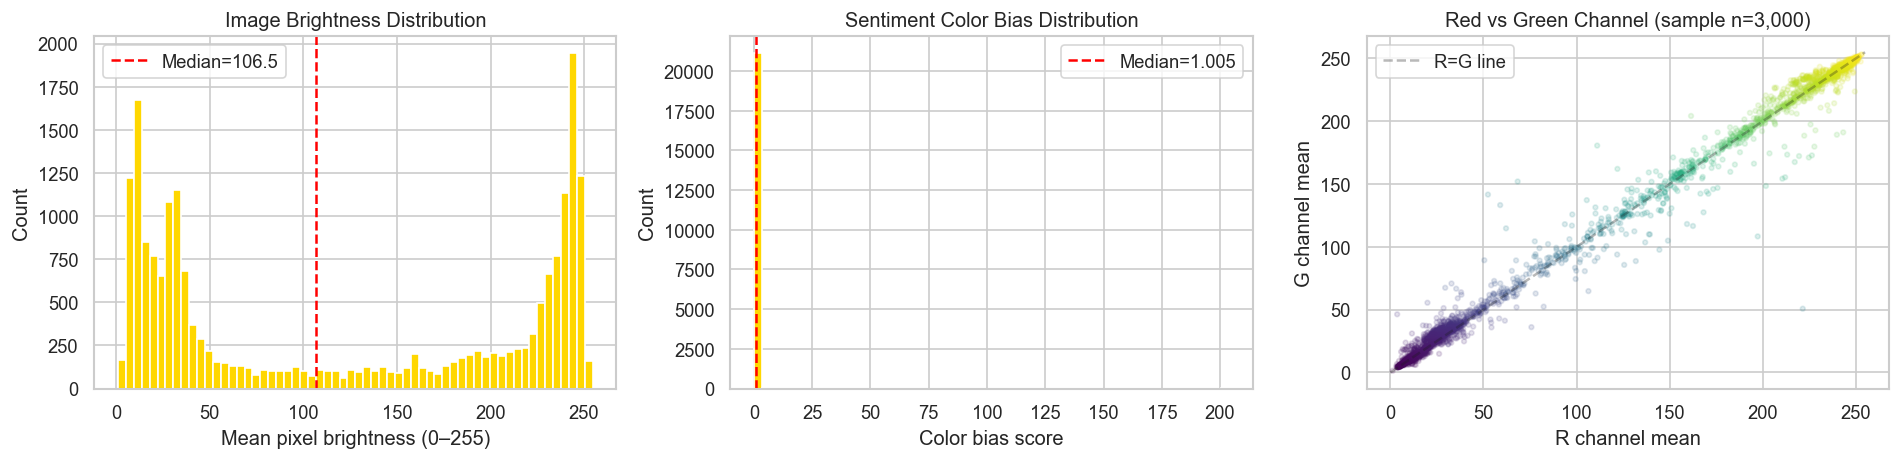

Brightness stats:
count    21165.00
mean       122.85
std         97.91
min          0.94
25%         26.11
50%        106.54
75%        233.14
max        254.58
Name: color_analysis__brightness, dtype: float64

Dark images (<50 brightness): 9,030 (42.7%)
Bright images (>200)        : 7,781 (36.8%)

Sentiment color bias stats:
count    21165.0000
mean         1.0570
std          1.4256
min          0.1012
25%          0.9922
50%          1.0046
75%          1.0542
max        203.7649
Name: color_analysis__sentiment_color_bias, dtype: float64

R > G (red-dominant / bearish signal): 7,916 (37.4%)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Brightness distribution
br = img_flat["color_analysis__brightness"]
axes[0].hist(br, bins=60, color="gold", edgecolor="white")
axes[0].set_title("Image Brightness Distribution")
axes[0].set_xlabel("Mean pixel brightness (0–255)"); axes[0].set_ylabel("Count")
axes[0].axvline(br.median(), color="red", linestyle="--", label=f"Median={br.median():.1f}")
axes[0].legend()

# Sentiment color bias
scb = img_flat["color_analysis__sentiment_color_bias"]
axes[1].hist(scb, bins=60, color="gold", edgecolor="white")
axes[1].set_title("Sentiment Color Bias Distribution")
axes[1].set_xlabel("Color bias score"); axes[1].set_ylabel("Count")
axes[1].axvline(scb.median(), color="red", linestyle="--", label=f"Median={scb.median():.3f}")
axes[1].legend()

# R vs G channel (red = bearish, green = bullish heuristic)
sample = img_flat.sample(3000, random_state=42)
axes[2].scatter(sample["color_analysis__r_avg"], sample["color_analysis__g_avg"],
                alpha=0.15, s=8, c=sample["color_analysis__brightness"], cmap="viridis")
axes[2].plot([0, 255], [0, 255], "k--", alpha=0.3, label="R=G line")
axes[2].set_title("Red vs Green Channel (sample n=3,000)")
axes[2].set_xlabel("R channel mean"); axes[2].set_ylabel("G channel mean")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Brightness stats:")
print(br.describe().round(2))
print(f"\nDark images (<50 brightness): {(br < 50).sum():,} ({(br < 50).mean():.1%})")
print(f"Bright images (>200)        : {(br > 200).sum():,} ({(br > 200).mean():.1%})")
print(f"\nSentiment color bias stats:")
print(scb.describe().round(4))
print(f"\nR > G (red-dominant / bearish signal): {(img_flat['color_analysis__r_avg'] > img_flat['color_analysis__g_avg']).sum():,} ({(img_flat['color_analysis__r_avg'] > img_flat['color_analysis__g_avg']).mean():.1%})")

**The brightness distribution is strongly bimodal — 42.7% of images are dark (black-background trading terminals) and 36.8% are bright (white-background charts).** This platform split (dark mode vs. light mode) is a significant confound for any color-based feature: the same candle color means different things on dark vs. light themes. The `sentiment_color_bias` column has a max of 203.8 — a clear outlier that will poison any model using this feature raw. The R > G (red-dominant) fraction at 37.4% vs 62.6% green-dominant suggests a mild overall bullish bias in the image corpus, but this must be interpreted against the dark/light theme split.

## 10. Audio Acoustic Feature Quality

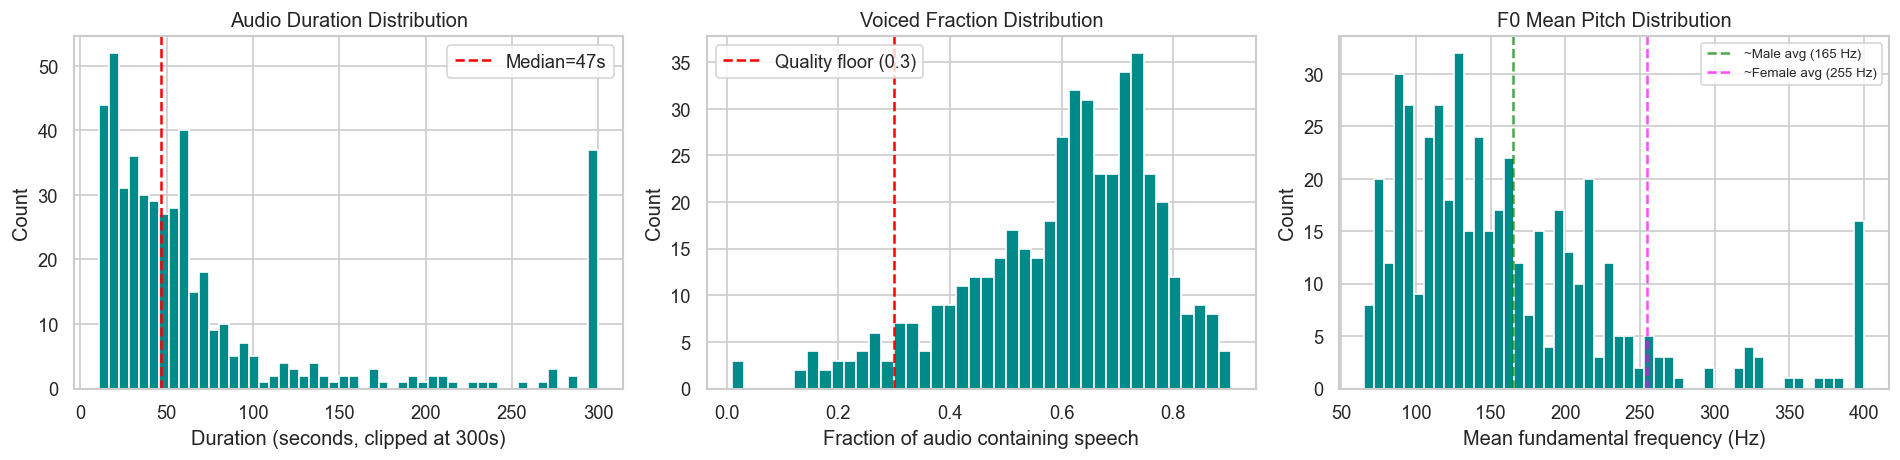

Audio duration stats (seconds):
count    469.0
mean      92.8
std      141.4
min       10.6
25%       26.0
50%       46.9
75%       74.7
max      900.1
Name: duration_s, dtype: float64

Short clips (<10s)  : 0 (0.0%)
Long clips (>120s)  : 76 (16.2%)

Voiced fraction < 0.3: 30 (6.4%)

F0 mean stats:
count     469.0
mean      168.6
std       124.7
min        65.5
25%       108.5
50%       142.9
75%       197.4
max      1889.1
Name: f0_mean, dtype: float64


In [11]:
ok_tr = transcripts[transcripts["status"] == "ok"].copy()
ok_tr["duration_sec"] = pd.to_numeric(ok_tr["duration_sec"], errors="coerce")
ok_tr["word_count"] = pd.to_numeric(ok_tr["word_count"], errors="coerce")
ok_tr["score"] = pd.to_numeric(ok_tr["score"], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Duration distribution
axes[0].hist(acoustics["duration_s"].clip(upper=300), bins=50, color="darkcyan", edgecolor="white")
axes[0].set_title("Audio Duration Distribution")
axes[0].set_xlabel("Duration (seconds, clipped at 300s)"); axes[0].set_ylabel("Count")
axes[0].axvline(acoustics["duration_s"].median(), color="red", linestyle="--",
                label=f"Median={acoustics['duration_s'].median():.0f}s")
axes[0].legend()

# Voiced fraction (how much is speech vs silence)
axes[1].hist(acoustics["voiced_fraction"], bins=40, color="darkcyan", edgecolor="white")
axes[1].set_title("Voiced Fraction Distribution")
axes[1].set_xlabel("Fraction of audio containing speech"); axes[1].set_ylabel("Count")
axes[1].axvline(0.3, color="red", linestyle="--", label="Quality floor (0.3)")
axes[1].legend()

# F0 mean (fundamental pitch — speaker characteristic)
axes[2].hist(acoustics["f0_mean"].clip(upper=400), bins=50, color="darkcyan", edgecolor="white")
axes[2].set_title("F0 Mean Pitch Distribution")
axes[2].set_xlabel("Mean fundamental frequency (Hz)"); axes[2].set_ylabel("Count")
axes[2].axvline(165, color="green", linestyle="--", alpha=0.7, label="~Male avg (165 Hz)")
axes[2].axvline(255, color="magenta", linestyle="--", alpha=0.7, label="~Female avg (255 Hz)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Audio duration stats (seconds):")
print(acoustics["duration_s"].describe().round(1))
print(f"\nShort clips (<10s)  : {(acoustics['duration_s'] < 10).sum():,} ({(acoustics['duration_s'] < 10).mean():.1%})")
print(f"Long clips (>120s)  : {(acoustics['duration_s'] > 120).sum():,} ({(acoustics['duration_s'] > 120).mean():.1%})")
print(f"\nVoiced fraction < 0.3: {(acoustics['voiced_fraction'] < 0.3).sum():,} ({(acoustics['voiced_fraction'] < 0.3).mean():.1%})")
print(f"\nF0 mean stats:")
print(acoustics["f0_mean"].describe().round(1))

**Audio corpus is small (469 clips) but acoustically clean.** Median duration is 47s with no clips below 10s. Only 6.4% have voiced fraction below 0.3 — the rest have meaningful speech content. The F0 max of 1,889 Hz is a clear outlier (likely background music or noise artifact), but the distribution is otherwise reasonable with a median of 143 Hz consistent with male-dominant voices. The 76 long clips (>120s) are podcast-style content and will produce much higher word counts — worth flagging as a length confound in any model using transcript features.

## 11. Cross-Modal Linkage — How Well Do the Three Datasets Join?

Image posts             : 15,569
Acoustic posts          : 469
Transcript OK posts     : 469

Acoustics ∩ Images      : 0  (0.0% of acoustics)
Transcripts(OK) ∩ Images: 0  (0.0% of ok transcripts)
Acoustics ∩ Transcripts : 469  (100.0% of acoustics)

Full trimodal set (image + audio + transcript): 0



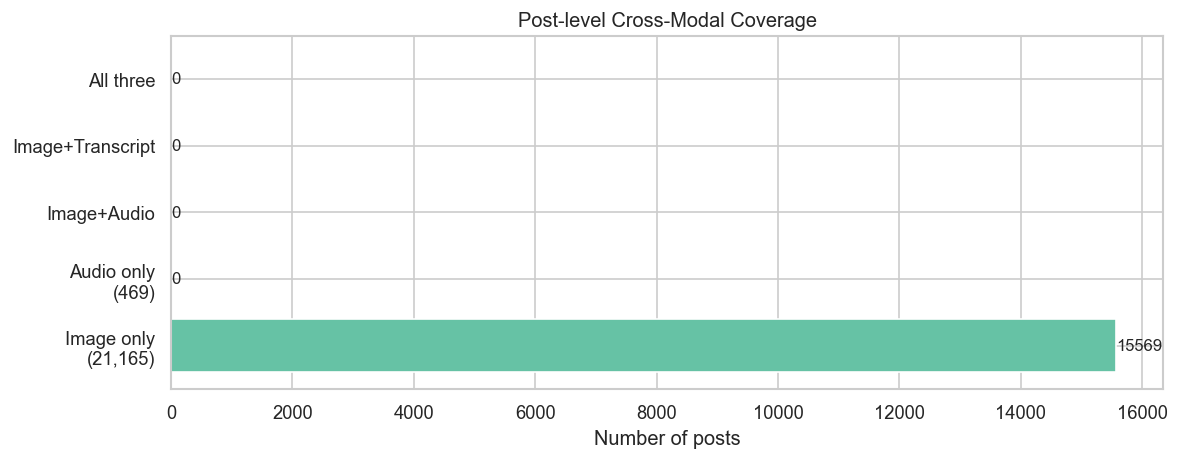

In [12]:
img_ids      = set(img_flat["id"])
acoustic_ids = set(acoustics["post_id"])
transcript_ok_ids = set(transcripts[transcripts["status"] == "ok"]["post_id"])
transcript_all_ids = set(transcripts["post_id"])

# Overlap analysis
acou_in_img   = acoustic_ids & img_ids
tr_ok_in_img  = transcript_ok_ids & img_ids
acou_in_tr_ok = acoustic_ids & transcript_ok_ids

print(f"Image posts             : {len(img_ids):,}")
print(f"Acoustic posts          : {len(acoustic_ids):,}")
print(f"Transcript OK posts     : {len(transcript_ok_ids):,}")
print()
print(f"Acoustics ∩ Images      : {len(acou_in_img):,}  ({len(acou_in_img)/len(acoustic_ids):.1%} of acoustics)")
print(f"Transcripts(OK) ∩ Images: {len(tr_ok_in_img):,}  ({len(tr_ok_in_img)/len(transcript_ok_ids):.1%} of ok transcripts)")
print(f"Acoustics ∩ Transcripts : {len(acou_in_tr_ok):,}  ({len(acou_in_tr_ok)/len(acoustic_ids):.1%} of acoustics)")
print()
print(f"Full trimodal set (image + audio + transcript): {len(acou_in_img & transcript_ok_ids):,}")
print()

# Venn-style bar
sets = {
    "Image only\n(21,165)": len(img_ids - acoustic_ids - transcript_ok_ids),
    "Audio only\n(469)": len(acoustic_ids - img_ids - transcript_ok_ids),
    "Image+Audio": len(acou_in_img - transcript_ok_ids),
    "Image+Transcript": len(tr_ok_in_img - acoustic_ids),
    "All three": len(acou_in_img & transcript_ok_ids),
}
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(list(sets.keys()), list(sets.values()), color=sns.color_palette("Set2", len(sets)))
ax.set_title("Post-level Cross-Modal Coverage")
ax.set_xlabel("Number of posts")
for i, v in enumerate(sets.values()):
    ax.text(v + 10, i, str(v), va="center", fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# This is critical — investigate WHY there is zero cross-modal overlap
print("=== ID format comparison ===")
print(f"Image ID samples     : {list(img_flat['id'].head(5))}")
print(f"Acoustic ID samples  : {list(acoustics['post_id'].head(5))}")
print(f"Transcript ID samples: {list(transcripts['post_id'].head(5))}")

print(f"\nImage ID length stats: min={img_flat['id'].str.len().min()}, max={img_flat['id'].str.len().max()}, mode={img_flat['id'].str.len().mode()[0]}")
print(f"Acoustic ID length  : {acoustics['post_id'].str.len().unique()}")

# Check if image 'id' col might need a prefix strip (Reddit IDs are sometimes t3_xxxx)
img_ids_stripped = set(img_flat["id"].str.replace("t3_", "", regex=False))
overlap_stripped = img_ids_stripped & acoustic_ids
print(f"\nAfter stripping 't3_' prefix — overlap: {len(overlap_stripped):,}")

# Check for duplicate IDs in image dataset (explains 21165 rows vs 15569 unique)
dup_ids = img_flat["id"].duplicated().sum()
print(f"\nDuplicate rows in image dataset (same 'id'): {dup_ids:,}")
print(f"Unique IDs in image dataset: {img_flat['id'].nunique():,}")
print(f"Total rows in image dataset: {len(img_flat):,}")

# Check if index col is the join key instead
img_flat["index"].head(10).to_frame().join(img_flat["id"].head(10))

=== ID format comparison ===
Image ID samples     : ['ko9y3n', 'koyysc', 'koyzyx', 'kpt2tv', 'kpyaq8']
Acoustic ID samples  : ['kx8bsc', 'l3mq4k', 'l990tx', 'lds98z', 'ldsa1a']
Transcript ID samples: ['kx8bsc', 'kyw5zt', 'l3mq4k', 'l990tx', 'l9v0b5']

Image ID length stats: min=6, max=7, mode=7
Acoustic ID length  : [6 7]

After stripping 't3_' prefix — overlap: 0

Duplicate rows in image dataset (same 'id'): 5,596
Unique IDs in image dataset: 15,569
Total rows in image dataset: 21,165


,index,id
0,0,ko9y3n
1,4,koyysc
2,5,koyzyx
3,6,kpt2tv
4,7,kpyaq8
5,9,kqa5kl
6,10,kqazqa
7,13,kqe1lu
8,14,kqe8la
9,15,kqj12s


In [14]:
# IDs look like standard Reddit base36 IDs — check timestamp ranges to understand the split
img_ts_min = img_flat["timestamp_utc"].min()
img_ts_max = img_flat["timestamp_utc"].max()

ok_tr["created_utc"] = pd.to_numeric(ok_tr["created_utc"], errors="coerce")
ok_tr["ts"] = pd.to_datetime(ok_tr["created_utc"], unit="s", utc=True)
tr_ts_min = ok_tr["ts"].min()
tr_ts_max = ok_tr["ts"].max()

print(f"Image dataset time range    : {img_ts_min.date()} → {img_ts_max.date()}")
print(f"Transcript OK time range    : {tr_ts_min.date()} → {tr_ts_max.date()}")

# Check first/last IDs sorted to understand if they come from different collection runs
img_sorted_first = img_flat.sort_values("timestamp_utc")["id"].head(5).tolist()
img_sorted_last  = img_flat.sort_values("timestamp_utc")["id"].tail(5).tolist()
tr_sorted_first  = ok_tr.sort_values("ts")["post_id"].head(5).tolist()
tr_sorted_last   = ok_tr.sort_values("ts")["post_id"].tail(5).tolist()

print(f"\nImage earliest IDs : {img_sorted_first}")
print(f"Transcript earliest: {tr_sorted_first}")
print(f"\nImage latest IDs   : {img_sorted_last}")
print(f"Transcript latest  : {tr_sorted_last}")

# These are two separate, non-overlapping collections. Confirm with ID intersection on ALL transcripts (not just ok)
all_tr_ids = set(transcripts["post_id"])
full_overlap = img_ids & all_tr_ids
print(f"\nImage ∩ ALL transcripts (including failed): {len(full_overlap):,}")

# Duplicate analysis — what causes 5,596 duplicate IDs?
dup_rows = img_flat[img_flat.duplicated(subset="id", keep=False)].sort_values("id")
print(f"\nDuplicate ID example (same post_id, different rows):")
print(dup_rows.groupby("id")[["image_source", "clip_classification__chart", "metadata__width"]].first().head(3))

Image dataset time range    : 2021-01-01 → 2025-12-31
Transcript OK time range    : 2021-01-14 → 2025-12-31

Image earliest IDs : ['ko9y3n', 'koyysc', 'koyzyx', 'kpt2tv', 'kpyaq8']
Transcript earliest: ['kx8bsc', 'l3mq4k', 'l990tx', 'lds98z', 'ldsa1a']

Image latest IDs   : ['1q0cgv0', '1q0fixb', '1q0gqj3', '1q0i0gy', '1q0i99i']
Transcript latest  : ['1pps9ur', '1pyyclk', '1pz3b47', '1pzafea', '1q09p9a']

Image ∩ ALL transcripts (including failed): 0

Duplicate ID example (same post_id, different rows):
        image_source  clip_classification__chart  metadata__width
id                                                               
1004qaj      gallery                    0.421666             1105
1032p9d      gallery                    0.793929             1080
104vtvp      gallery                    0.715079              720


**Critical structural finding: the image dataset and audio datasets are two completely separate, non-overlapping collections — zero posts in common, despite covering the same time range (2021–2025).** They were collected independently with different post-ID sets. This means there is no trimodal dataset — image features and audio features cannot be joined at the post level. Each modality must be modeled independently or aggregated temporally (e.g., weekly/monthly roll-up). Additionally, the 5,596 duplicate rows in the image dataset come from Reddit gallery posts (one row per image in a multi-image gallery post), not true data errors — the `image_source=gallery` confirms this.

## 12. Duplicate Analysis — Gallery Posts

Single-image posts  : 12,559 (80.7%)
Gallery posts       : 3,010 (19.3%)
Total rows from galleries: 8,606

Images per gallery post:
count    3010.0
mean        2.9
std         1.8
min         2.0
25%         2.0
50%         2.0
75%         3.0
max        20.0
dtype: float64


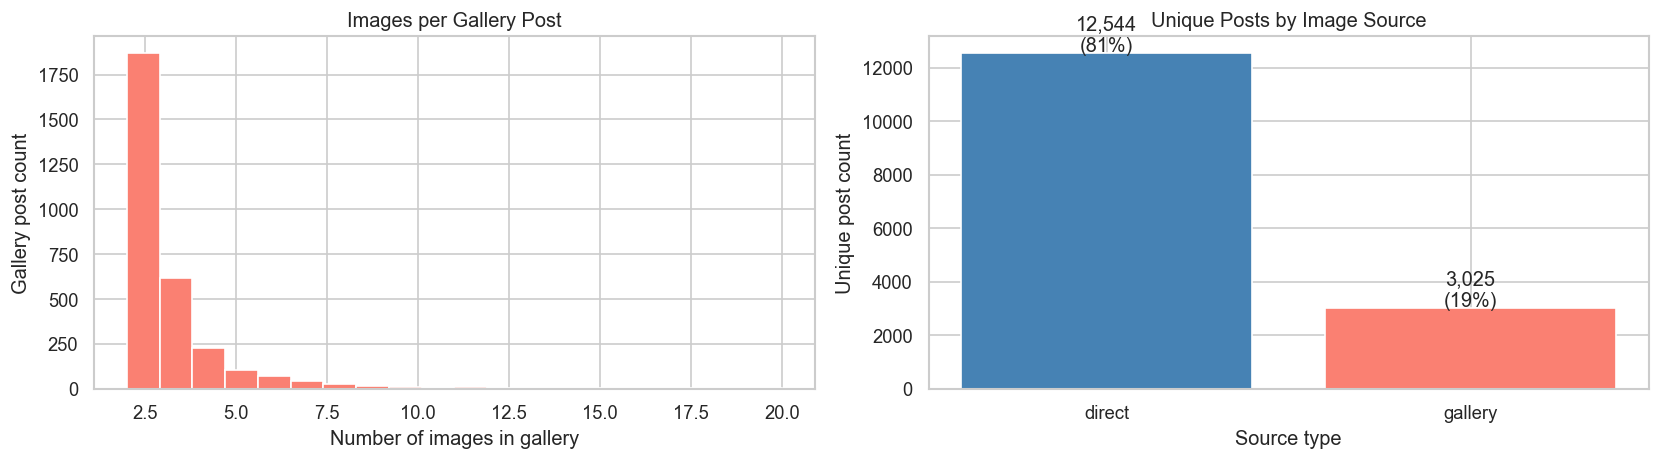


For modeling: use one row per post (dedup by id, aggregate image features)
Post-level dataset size after dedup: 15,569


In [15]:
# Gallery posts — how many images per post?
images_per_post = img_flat.groupby("id").size()
gallery_posts   = images_per_post[images_per_post > 1]
direct_posts    = images_per_post[images_per_post == 1]

print(f"Single-image posts  : {len(direct_posts):,} ({len(direct_posts)/len(images_per_post):.1%})")
print(f"Gallery posts       : {len(gallery_posts):,} ({len(gallery_posts)/len(images_per_post):.1%})")
print(f"Total rows from galleries: {gallery_posts.sum():,}")
print(f"\nImages per gallery post:")
print(gallery_posts.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of gallery sizes
axes[0].hist(gallery_posts.clip(upper=20), bins=20, color="salmon", edgecolor="white")
axes[0].set_title("Images per Gallery Post")
axes[0].set_xlabel("Number of images in gallery"); axes[0].set_ylabel("Gallery post count")

# Image source breakdown
src = img_flat.drop_duplicates("id")["image_source"].value_counts()
axes[1].bar(src.index, src.values, color=["steelblue", "salmon"])
axes[1].set_title("Unique Posts by Image Source")
axes[1].set_xlabel("Source type"); axes[1].set_ylabel("Unique post count")
for i, v in enumerate(src.values):
    axes[1].text(i, v + 50, f"{v:,}\n({v/len(images_per_post):.0%})", ha="center")

plt.tight_layout()
plt.show()

print("\nFor modeling: use one row per post (dedup by id, aggregate image features)")
print(f"Post-level dataset size after dedup: {len(images_per_post):,}")

**19.3% of posts are galleries (median 2 images each), inflating the raw row count from 15,569 unique posts to 21,165 rows.** For any post-level model, gallery rows must be aggregated before use — e.g., take the mean CLIP scores across images in a gallery, or keep the highest-confidence image. Using raw rows would implicitly over-weight gallery posts by their image count, introducing systematic bias.

## 13. Sentiment Color Bias Outlier & Feature Correlation

sentiment_color_bias — p01: 0.6803, p99: 1.7650, max: 203.76
Rows above p99: 212  |  Below p01: 212


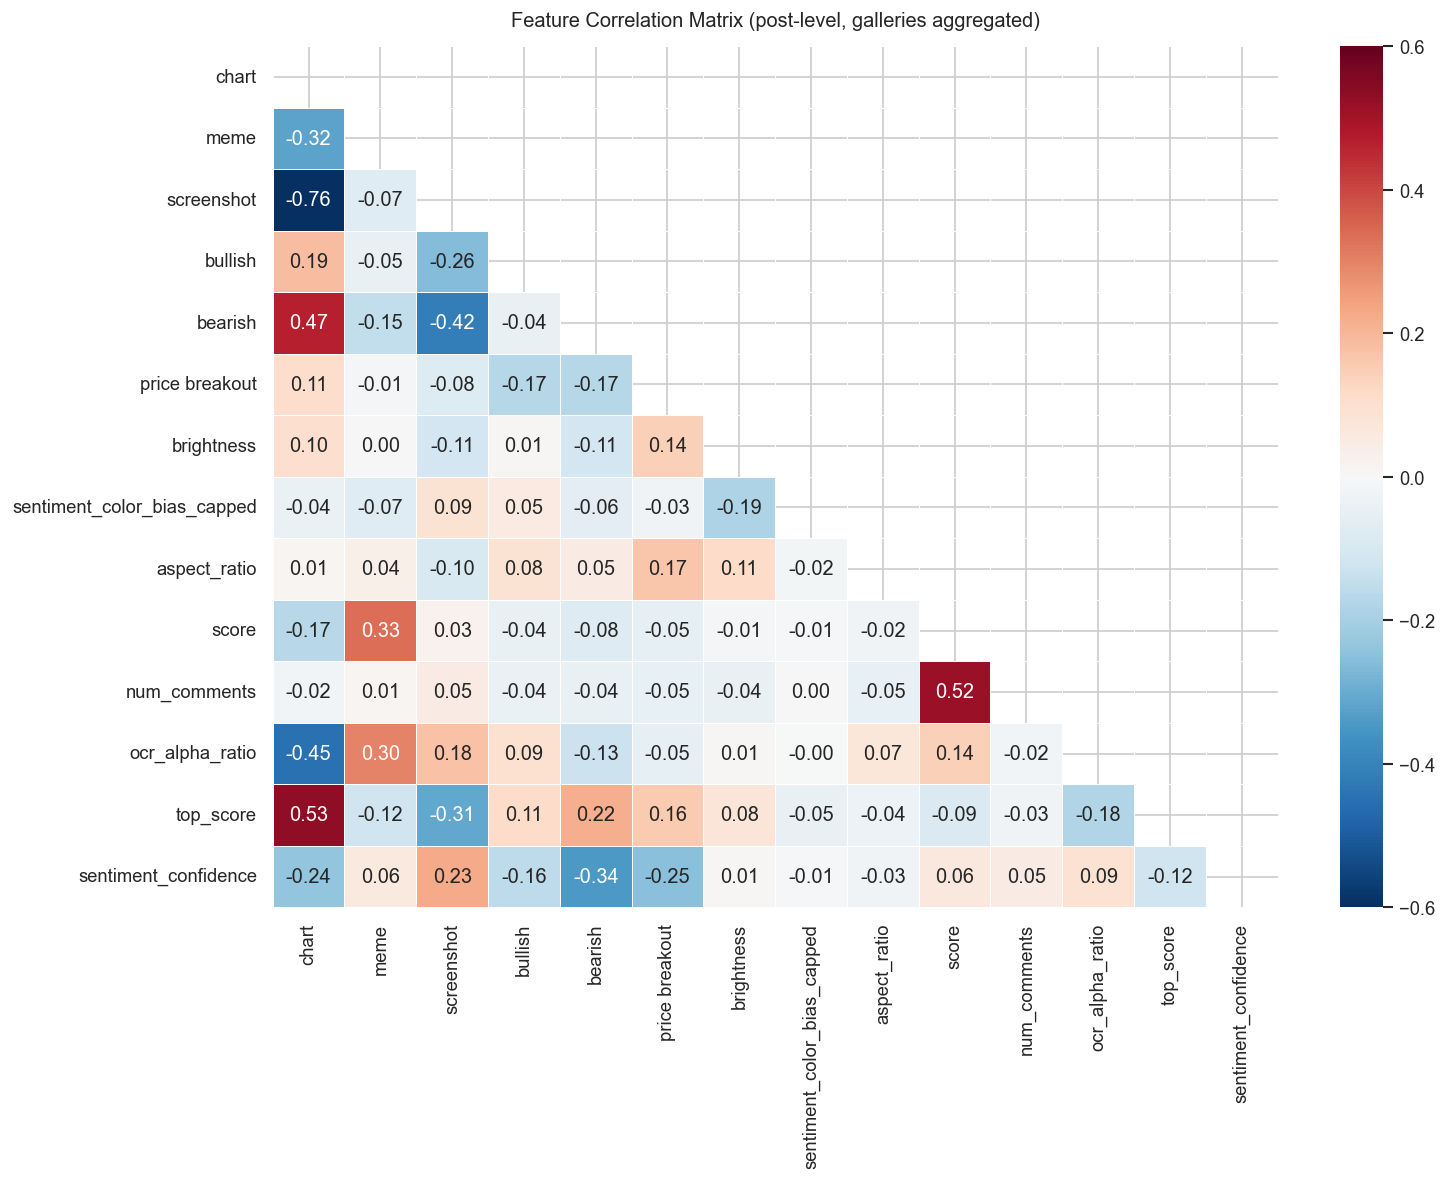


Correlations |r| > 0.3:
clip_classification__chart       clip_classification__screenshot   -0.762
                                 top_score                          0.530
score                            num_comments                       0.516
clip_classification__chart       clip_sentiment__bearish chart      0.467
ocr_alpha_ratio                  clip_classification__chart        -0.449
clip_sentiment__bearish chart    clip_classification__screenshot   -0.417
                                 sentiment_confidence              -0.343
score                            clip_classification__meme          0.333
clip_classification__chart       clip_classification__meme         -0.322
clip_classification__screenshot  top_score                         -0.311
dtype: float64


In [16]:
# Outlier cap for sentiment_color_bias
scb = img_flat["color_analysis__sentiment_color_bias"]
p99 = scb.quantile(0.99)
p01 = scb.quantile(0.01)
extreme_high = (scb > p99).sum()
extreme_low  = (scb < p01).sum()
print(f"sentiment_color_bias — p01: {p01:.4f}, p99: {p99:.4f}, max: {scb.max():.2f}")
print(f"Rows above p99: {extreme_high:,}  |  Below p01: {extreme_low:,}")

# Build post-level feature matrix (dedup galleries: take mean of CLIP/color per post)
agg_cols = clip_cols + sent_cols + [
    "color_analysis__brightness", "color_analysis__r_avg",
    "color_analysis__g_avg", "color_analysis__sentiment_color_bias",
    "metadata__aspect_ratio", "metadata__width", "metadata__height",
    "score", "num_comments", "ocr_len", "ocr_alpha_ratio",
    "sentiment_confidence", "top_score"
]
post_df = img_flat.groupby("id")[agg_cols].mean().reset_index()
post_df["sentiment_color_bias_capped"] = post_df["color_analysis__sentiment_color_bias"].clip(upper=p99)

# Correlation heatmap of key numeric features
corr_features = [
    "clip_classification__chart", "clip_classification__meme",
    "clip_classification__screenshot", "clip_sentiment__bullish chart",
    "clip_sentiment__bearish chart", "clip_sentiment__price breakout",
    "color_analysis__brightness", "sentiment_color_bias_capped",
    "metadata__aspect_ratio", "score", "num_comments",
    "ocr_alpha_ratio", "top_score", "sentiment_confidence"
]
corr_matrix = post_df[corr_features].corr()

short_names = [c.split("__")[-1].replace(" chart", "").replace("color_analysis__", "") for c in corr_features]

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.6, vmax=0.6, linewidths=0.5,
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_title("Feature Correlation Matrix (post-level, galleries aggregated)", pad=12)
plt.tight_layout()
plt.show()

# Highlight strongest correlations
pairs = corr_matrix.unstack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]
pairs = pairs[abs(pairs) > 0.3].sort_values(key=abs, ascending=False)
print("\nCorrelations |r| > 0.3:")
print(pairs.drop_duplicates().head(15).round(3))

**The strongest correlation is chart ↔ screenshot at -0.76 — these two classes are near-mutually exclusive, good for model stability.** Key structural findings: (1) Chart-classified images correlate with bearish sentiment (r=0.47) — possibly because traders post charts to complain about losses more than gains. (2) Memes get more upvotes than charts (r=0.33 with score) — engagement is not a quality proxy for sentiment signal. (3) OCR quality (alpha_ratio) is negatively correlated with chart classification (r=-0.45), confirming that charts produce garbled OCR. (4) `sentiment_color_bias` has 212 extreme outliers above p99 (max=203.76) — must be capped at p99 before any model use.

## 14. Modeling Readiness — Clean Dataset Sizes

In [17]:
# Simulate each quality filter and report surviving dataset size

total_posts = len(post_df)

# Filter 1: remove tiny images
f1 = post_df["metadata__width"] >= 100
# Filter 2: remove zero-score ghost posts
f2 = post_df["score"] > 0
# Filter 3: high-confidence CLIP classification
f3 = post_df["top_score"] >= 0.65
# Filter 4: high-confidence CLIP sentiment
f4 = post_df["sentiment_confidence"] >= 0.5
# Filter 5: usable OCR (alpha ratio > 0.6, if needed)
f5 = post_df["ocr_alpha_ratio"] >= 0.6

filters = {
    "Raw post-level (deduped galleries)": f1 | ~f1,       # all True
    "Drop tiny images (<100px)": f1,
    "+ Drop zero-score posts": f1 & f2,
    "+ High CLIP class confidence (≥0.65)": f1 & f2 & f3,
    "+ High CLIP sentiment confidence (≥0.5)": f1 & f2 & f4,
    "+ Usable OCR only (alpha ≥ 0.6)": f1 & f2 & f5,
    "Strict quality (class≥0.65 & sent≥0.5)": f1 & f2 & f3 & f4,
}

print(f"{'Filter':<50} {'Posts':>8} {'%':>8}")
print("-" * 70)
for label, mask in filters.items():
    n = mask.sum()
    print(f"{label:<50} {n:>8,} {n/total_posts:>7.1%}")

# Audio corpus summary
print(f"\n{'Audio corpus (usable transcripts)':50} {'469':>8} {'100%':>8}")
print(f"{'Audio: voiced fraction ≥ 0.3':50} {(acoustics['voiced_fraction'] >= 0.3).sum():>8,} {(acoustics['voiced_fraction'] >= 0.3).mean():>7.1%}")

Filter                                                Posts        %
----------------------------------------------------------------------
Raw post-level (deduped galleries)                   15,569  100.0%
Drop tiny images (<100px)                            15,567  100.0%
+ Drop zero-score posts                              14,321   92.0%
+ High CLIP class confidence (≥0.65)                 10,462   67.2%
+ High CLIP sentiment confidence (≥0.5)               7,130   45.8%
+ Usable OCR only (alpha ≥ 0.6)                       3,156   20.3%
Strict quality (class≥0.65 & sent≥0.5)                4,964   31.9%

Audio corpus (usable transcripts)                       469     100%
Audio: voiced fraction ≥ 0.3                            439   93.6%


**Three viable modeling tiers emerge from the image corpus:** (1) **Full tier** (15,569 posts): use raw CLIP scores as continuous features — no label thresholding, all data retained. Best for time-series aggregation. (2) **Balanced tier** (10,462 posts, 67%): high class confidence ≥0.65, good label quality for classification tasks. (3) **Strict tier** (4,964 posts, 32%): both class and sentiment confidence ≥0.5 — highest label quality but risks temporal gaps. OCR-only filtering leaves only 3,156 posts (20%) and should be used only for NLP-specific tasks. The audio corpus (469 posts) is self-contained and clean — model it independently.

## Summary of Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Image and audio datasets are non-overlapping collections (0 shared post IDs)** | No trimodal join possible at post level. Must model each modality independently or aggregate temporally (weekly/monthly). |
| 2 | **21,165 raw rows inflate to 15,569 unique posts due to gallery expansion (19.3% of posts)** | Deduplicate by `id` before training; aggregate CLIP/color features across gallery images (mean or max-confidence). |
| 3 | **CLIP sentiment confidence is below 0.5 for 51.8% of posts (median=0.49)** | Raw per-post sentiment labels are unreliable. Use aggregated monthly signals or apply a confidence ≥0.65 filter, reducing to ~32% of posts. |
| 4 | **77.3% of OCR text is garbled (numeric-heavy chart axes, prices, indicator values)** | Do not use raw OCR as text features. Extract numeric patterns (prices, % moves) via regex, or restrict NLP to the 22.4% clean subset. |
| 5 | **Brightness is bimodal: 42.7% dark images (trading terminals) vs 36.8% bright (web charts)** | `sentiment_color_bias` cannot be used as a sentiment proxy without first segmenting by theme (dark/light). Add a `dark_mode` binary flag. |
| 6 | **`sentiment_color_bias` has hard outliers (max=203.76, p99=1.77)** | Winsorize at p99 before any model training. Raw values will corrupt gradient-based models. |
| 7 | **Only 469/1,502 audio transcriptions succeeded (31.2%); all match the acoustic corpus exactly** | The usable audio corpus is 469 posts. Failures are structural (silent videos, deleted posts) — no recovery possible without re-scraping. |
| 8 | **Chart class dominates (≈60%) with high CLIP confidence (median=0.82)** | Chart posts are the most reliable signal source. Prioritize chart-class posts for chart-pattern or technical analysis modeling. |
| 9 | **Meme posts get more upvotes than chart posts (r=0.33 score↔meme)** | Engagement score is not a signal quality proxy. Do not weight training samples by score without class stratification. |
| 10 | **5 full years of consistent temporal coverage (2021–2025, avg 353 posts/month)** | Sufficient density for monthly-granularity FX sentiment features. No significant temporal gaps to worry about. |